# EMA 21/13/8 Crypto Strategy — Bybit Live Data (Migrated from MT5)

> **Migration note**: This notebook was migrated from `03_strategy03_crypto.ipynb` (MT5/CSV-cache version).
> The execution layer changed from **local CSV cache** to **live Bybit REST API** (`pybit` via `market.data_fetcher`).
> Strategy logic is **byte-identical** to the MT5 version — EMA calculations, trend rules, signal geometry, and risk formula are unchanged.

## What changed vs. `03_strategy03_crypto.ipynb`
| Original (CSV cache) | This notebook (Bybit live) |
|---------------------|--------------------------|
| Reads `./data/<symbol>/<tf>/ohlcv.csv` | Fetches live from Bybit REST |
| Needs pre-cached data | Always up-to-date |
| Offline, reproducible | Online, reflects current market |
| Any symbol in cache | Any Bybit Linear symbol |

## What stayed the same
- EMA 8/13/21 calculation (`strategy.crypto_core.add_emas`)
- H1 trend rules (`strategy.crypto_core.merge_h1_trend_onto_m5`)
- Signal generation (`strategy.setup.list_setup_signals`)
- Backtest engine (`strategy.backtest.run_backtest`)
- Risk formula (`risk_cash = balance × risk_per_trade`)
- Result output format (`./results/strategy03_crypto/...`)


In [ ]:
# SECTION 1 — Imports and parameters
import warnings
warnings.filterwarnings("ignore")

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# Resolve project root (notebooks/ -> parent)
_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

# Load .env
try:
    from dotenv import load_dotenv
    _env = _ROOT / ".env"
    if _env.exists():
        load_dotenv(_env)
except ImportError:
    pass

from strategy.crypto_core import EMA_FAST, EMA_MID, EMA_SLOW, default_crypto_tick

# === User parameters ===
SYMBOL = "ETHUSDT"
# Other Bybit symbols: "ETHUSDT", "SOLUSDT", "XRPUSDT", "BNBUSDT", "ADAUSDT"
TF_ENTRY = "M5"
TF_TREND = "H1"

LOOKBACK_BARS      = 5
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN = 60
RR                 = 1.0
PIP_SIZE           = default_crypto_tick(SYMBOL)
PENDING_OFFSET_PIPS = float(PENDING_OFFSET_TICKS)

START_BALANCE  = 10000.0
RISK_PER_TRADE = 0.01

BARS_M5 = 8000   # last N closed M5 candles to backtest over
BARS_H1 = 2000   # H1 bars for trend context

CATEGORY = "linear"
TESTNET  = os.getenv("BYBIT_TESTNET", "false").lower() == "true"

print(f"Symbol={SYMBOL}, Trend={TF_TREND}, Entry={TF_ENTRY}")
print(f"PIP_SIZE={PIP_SIZE}, offset_ticks={PENDING_OFFSET_TICKS}")
print(f"Testnet={TESTNET}")


Symbol=BTCUSDT, Trend=H1, Entry=M5
PIP_SIZE=1.0, offset_ticks=3.0
Testnet=False


In [2]:
# SECTION 2 — Load OHLCV from local cache (./data/SYMBOL/TIMEFRAME/ohlcv.csv)
DATA_DIR = _ROOT / "notebooks" / "data"

_TEHRAN = "Asia/Tehran"

def _load_csv(symbol: str, tf: str, limit: int) -> pd.DataFrame:
    csv_path = DATA_DIR / symbol / tf / "ohlcv.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Cache file not found: {csv_path}\n"
            f"Run 00_data_fetching_bybit.ipynb first to populate the cache."
        )
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    if df.index.tz is None:
        # Backwards-compat: old CSVs without tz info are treated as Tehran time
        df.index = df.index.tz_localize(_TEHRAN)
    df = df.sort_index()
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)
    df = df[["open", "high", "low", "close", "volume"]]
    if limit and len(df) > limit:
        df = df.iloc[-limit:]
    return df


def show_local(df, n=3):
    """Display last n rows with Tehran local time."""
    return df.tail(n).copy().set_index(df.tail(n).index.tz_convert(_TEHRAN))


print(f"Loading {TF_ENTRY} candles for {SYMBOL} from cache...")
m5 = _load_csv(SYMBOL, TF_ENTRY, limit=BARS_M5)
print(f"  -> {len(m5):,} rows  |  Tehran: {m5.index[-1]}")

print(f"Loading {TF_TREND} candles for {SYMBOL} from cache...")
h1 = _load_csv(SYMBOL, TF_TREND, limit=BARS_H1)
print(f"  -> {len(h1):,} rows  |  Tehran: {h1.index[-1]}")

display(show_local(m5))
display(show_local(h1))

Loading M5 candles for BTCUSDT from cache...
  -> 8,000 rows  |  Tehran: 2026-05-13 17:45:00+03:30
Loading H1 candles for BTCUSDT from cache...
  -> 1,999 rows  |  Tehran: 2026-05-13 16:30:00+03:30


,open,high,low,close,volume
time,,,,,
2026-05-13 17:35:00+03:30,79600.0,79709.1,79559.2,79639.1,484.134
2026-05-13 17:40:00+03:30,79639.1,79748.5,79627.0,79664.1,313.703
2026-05-13 17:45:00+03:30,79664.1,79731.5,79611.8,79666.4,470.602


,open,high,low,close,volume
time,,,,,
2026-05-13 14:30:00+03:30,80774.2,80818.5,80456.1,80460.1,2497.178
2026-05-13 15:30:00+03:30,80460.1,80560.0,79804.3,80150.0,6901.069
2026-05-13 16:30:00+03:30,80150.0,80304.6,79525.0,79605.9,6047.340


In [3]:
# SECTION 3 — Build EMA 8/13/21 on both timeframes
from strategy.crypto_core import add_emas

m5 = add_emas(m5)
h1 = add_emas(h1)

print("EMA columns added.")
display(h1[[f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,ema_8,ema_13,ema_21
time,,,
2026-05-13 12:30:00+03:30,81055.126161,80977.142026,80926.117754
2026-05-13 13:30:00+03:30,80992.698125,80948.150308,80912.307049
2026-05-13 14:30:00+03:30,80874.342986,80878.428835,80871.197317
2026-05-13 15:30:00+03:30,80713.377878,80774.367573,80805.633925
2026-05-13 16:30:00+03:30,80467.271683,80607.443634,80696.567204


In [4]:
# SECTION 4 — Merge H1 trend onto M5 (no lookahead)
from strategy.crypto_core import merge_h1_trend_onto_m5

m5_ctx = merge_h1_trend_onto_m5(m5, h1)

print(m5_ctx["trend"].value_counts(dropna=False))
display(m5_ctx[["close", "trend"]].tail(8))


trend
bull    3952
bear    2440
flat    1608
Name: count, dtype: int64


,close,trend
time,,
2026-05-13 17:10:00+03:30,79806.0,bear
2026-05-13 17:15:00+03:30,79604.7,bear
2026-05-13 17:20:00+03:30,79705.9,bear
2026-05-13 17:25:00+03:30,79605.9,bear
2026-05-13 17:30:00+03:30,79600.0,bear
2026-05-13 17:35:00+03:30,79639.1,bear
2026-05-13 17:40:00+03:30,79664.1,bear
2026-05-13 17:45:00+03:30,79666.4,bear


In [5]:
# SECTION 5 — Run backtest
from strategy.backtest import run_backtest

trades_df, equity_curve = run_backtest(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)
print(f"Total trades: {len(trades_df)}")
display(trades_df.tail(10))


Total trades: 180


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
170,2026-05-12 18:50:00+03:30,2026-05-12 20:15:00+03:30,sell,80377.0,80857.6,79896.4,79896.4,0.001245,0.598420,10008.756608,win
171,2026-05-13 00:00:00+03:30,2026-05-13 01:00:00+03:30,sell,80676.2,80833.0,80519.4,80519.4,0.001241,0.194527,10008.951135,win
172,2026-05-13 01:10:00+03:30,2026-05-13 01:30:00+03:30,sell,80512.3,80691.1,80333.5,80691.1,0.001243,-0.222277,10008.728859,loss
173,2026-05-13 02:45:00+03:30,2026-05-13 03:05:00+03:30,sell,80575.4,80690.9,80459.9,80459.9,0.001242,0.143469,10008.872328,win
174,2026-05-13 03:15:00+03:30,2026-05-13 03:50:00+03:30,sell,80428.1,80634.6,80221.6,80634.6,0.001244,-0.256979,10008.615349,loss
175,2026-05-13 09:45:00+03:30,2026-05-13 10:20:00+03:30,buy,81065.0,80959.2,81170.8,80959.2,0.001235,-0.130625,10008.484724,loss
176,2026-05-13 11:35:00+03:30,2026-05-13 12:15:00+03:30,buy,80999.6,80862.0,81137.2,81137.2,0.001236,0.170022,10008.654745,win
177,2026-05-13 12:25:00+03:30,2026-05-13 14:00:00+03:30,buy,81153.0,80901.3,81404.7,80901.3,0.001233,-0.310423,10008.344322,loss
178,2026-05-13 15:40:00+03:30,2026-05-13 15:50:00+03:30,sell,80453.1,80671.0,80235.2,80235.2,0.001244,0.271067,10008.615389,win
179,2026-05-13 16:00:00+03:30,2026-05-13 17:15:00+03:30,sell,80132.0,80563.0,79701.0,79701.0,0.001249,0.538326,10009.153715,win


In [6]:
# SECTION 5b — Entry signals vs actual fills
import importlib
import strategy.backtest as _backtest_mod
importlib.reload(_backtest_mod)
from strategy.setup import list_setup_signals, list_trade_entries

entry_signals_df = list_setup_signals(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
)
entry_fills_df = list_trade_entries(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)

print(f"Signals (pending-setup bars): {len(entry_signals_df)}")
print(f"Fills   (pending triggered) : {len(entry_fills_df)}")
display(entry_signals_df.head(10))
display(entry_fills_df.head(10))

# Save signals
_out = Path("./results") / "strategy03_crypto" / SYMBOL / TF_ENTRY
_out.mkdir(parents=True, exist_ok=True)
entry_signals_df.to_csv(_out / "entry_signals.csv", index=False)
entry_fills_df.to_csv(_out / "entry_fills.csv", index=False)
print(f"Saved signals -> {_out}")


Signals (pending-setup bars): 6387
Fills   (pending triggered) : 181


,signal_bar_index,signal_bar_time,trend,side,entry,sl,tp,qty
0,5,2026-04-15 23:35:00+03:30,bull,buy,75125.7,74783.9,75467.5,0.001331
1,6,2026-04-15 23:40:00+03:30,bull,buy,75103.0,74651.4,75554.6,0.001332
2,7,2026-04-15 23:45:00+03:30,bull,buy,75103.0,74552.8,75653.2,0.001332
3,8,2026-04-15 23:50:00+03:30,bull,buy,75052.6,74453.9,75651.3,0.001332
4,9,2026-04-15 23:55:00+03:30,bull,buy,75002.0,74453.9,75550.1,0.001333
5,10,2026-04-16 00:00:00+03:30,bull,buy,74878.8,74453.9,75303.7,0.001335
6,11,2026-04-16 00:05:00+03:30,bull,buy,74883.6,74453.9,75313.3,0.001335
7,12,2026-04-16 00:10:00+03:30,bull,buy,74883.6,74453.9,75313.3,0.001335
8,13,2026-04-16 00:15:00+03:30,bull,buy,74883.6,74487.3,75279.9,0.001335
9,14,2026-04-16 00:20:00+03:30,bull,buy,74883.6,74487.3,75279.9,0.001335


,signal_bar_time,signal_bar_index,entry_time,entry_bar_index,side,entry,sl,tp,qty
0,2026-04-16 00:40:00+03:30,18,2026-04-16 01:30:00+03:30,28,buy,74843.4,74677.0,75009.8,0.001336
1,2026-04-16 01:40:00+03:30,30,2026-04-16 02:05:00+03:30,35,buy,75135.3,74658.5,75612.1,0.001331
2,2026-04-16 03:50:00+03:30,56,2026-04-16 04:00:00+03:30,58,buy,74803.0,74520.3,75085.7,0.001337
3,2026-04-16 05:45:00+03:30,79,2026-04-16 05:55:00+03:30,81,buy,74721.5,74510.1,74932.9,0.001338
4,2026-04-16 06:05:00+03:30,83,2026-04-16 06:10:00+03:30,84,buy,75053.0,74554.3,75551.7,0.001332
5,2026-04-16 16:30:00+03:30,208,2026-04-16 17:10:00+03:30,216,sell,74532.0,74702.4,74361.6,0.001342
6,2026-04-16 19:30:00+03:30,244,2026-04-16 20:20:00+03:30,254,sell,74142.1,74874.0,73410.2,0.001349
7,2026-04-16 22:30:00+03:30,280,2026-04-16 23:00:00+03:30,286,buy,75072.3,74381.2,75763.4,0.001332
8,2026-04-17 12:30:00+03:30,448,2026-04-17 12:40:00+03:30,450,buy,75853.1,75157.1,76549.1,0.001318
9,2026-04-17 15:10:00+03:30,480,2026-04-17 15:20:00+03:30,482,buy,75539.4,75263.1,75815.7,0.001324


Saved signals -> results\strategy03_crypto\BTCUSDT\M5


In [7]:
# SECTION 6 — Metrics
def max_drawdown_pct(equity: pd.Series | None) -> float:
    if equity is None or len(equity) < 2:
        return 0.0
    eq   = pd.Series(equity).astype(float).dropna()
    peak = eq.cummax()
    dd   = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(trades: pd.DataFrame, start_balance: float, equity=None) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{"trades": 0, "win_rate_%": 0.0, "net_pnl": 0.0,
                               "profit_factor": 0.0, "max_drawdown_%": round(max_drawdown_pct(equity), 2),
                               "start_balance": start_balance, "end_balance": start_balance, "return_%": 0.0}])
    wins   = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]
    gp     = wins.sum() if not wins.empty else 0.0
    gl     = abs(losses.sum()) if not losses.empty else 0.0
    pf     = gp / gl if gl > 0 else np.nan
    end_b  = float(trades["balance_after"].iloc[-1])
    return pd.DataFrame([{
        "trades":          int(len(trades)),
        "win_rate_%":      round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl":         round(trades["pnl"].sum(), 2),
        "avg_pnl":         round(trades["pnl"].mean(), 2),
        "profit_factor":   round(float(pf), 3) if pd.notna(pf) else np.nan,
        "max_drawdown_%":  round(max_drawdown_pct(equity), 2),
        "start_balance":   round(start_balance, 2),
        "end_balance":     round(end_b, 2),
        "return_%":        round(((end_b / start_balance) - 1) * 100, 2),
    }])


if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"]   = trades_df["pnl"].cumsum()

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)


,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,180,58.89,9.15,0.05,1.258,0.06,10000.0,10009.15,0.09


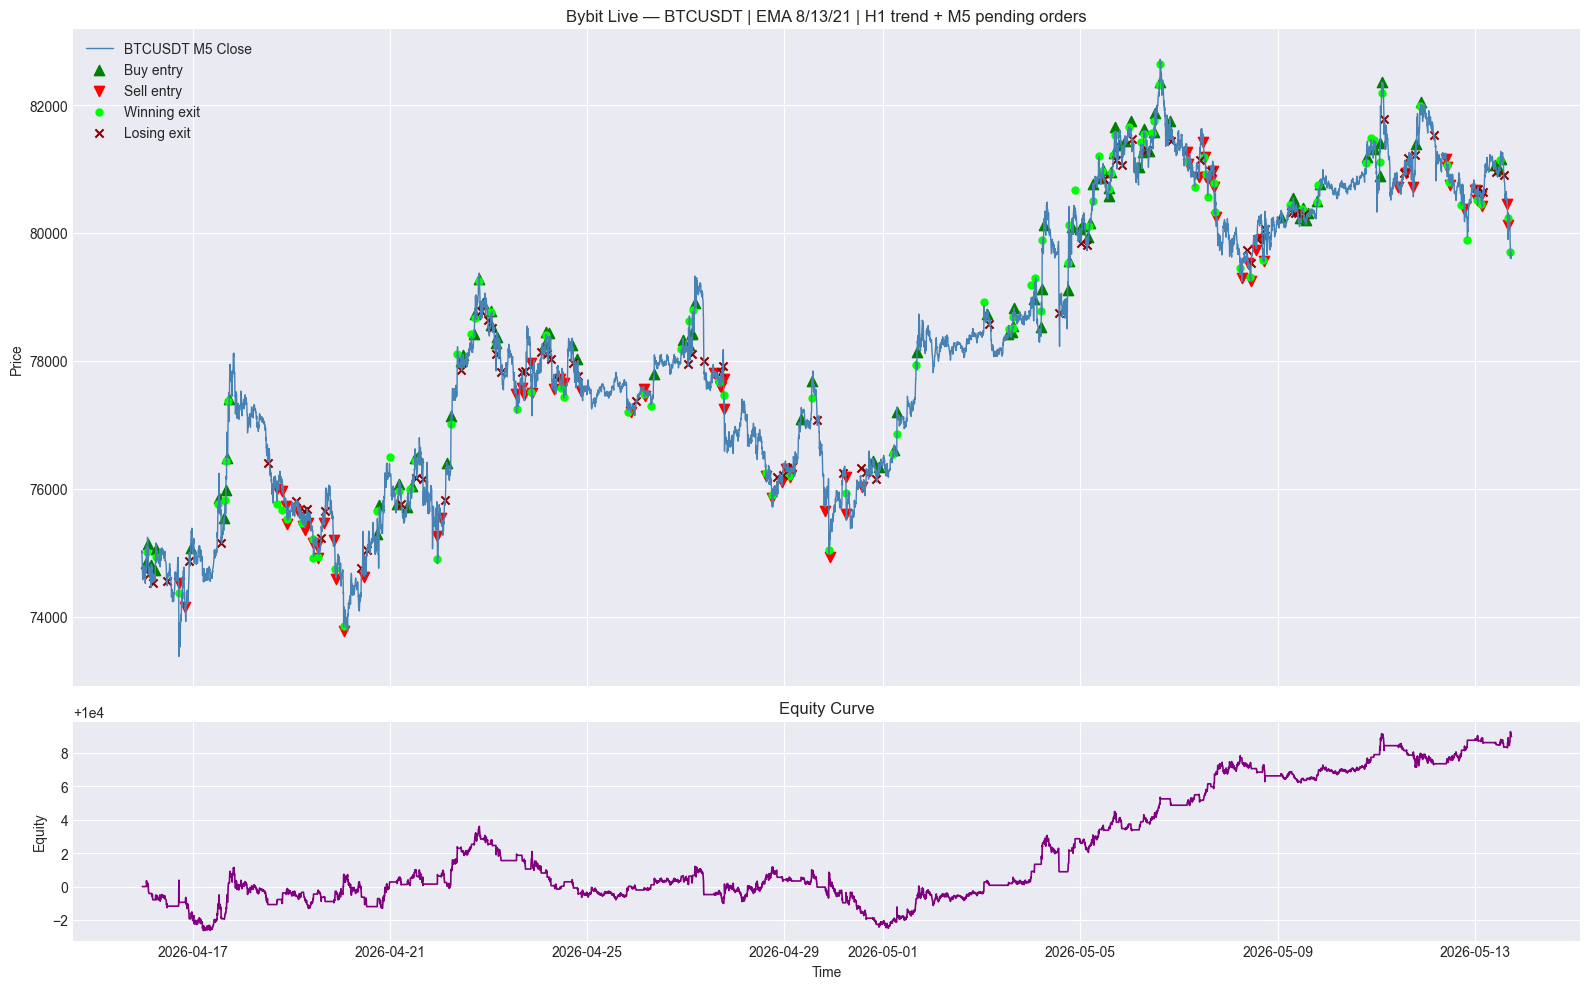

In [8]:
# SECTION 7 — Pilot result chart
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

ax_price.plot(m5_ctx.index, m5_ctx["close"],
              label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys  = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]
    ax_price.scatter(buys["entry_time"],  buys["entry"],  marker="^", color="green",   s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red",     s=55, label="Sell entry")
    ax_price.scatter(trades_df[trades_df["pnl"] > 0]["exit_time"],
                     trades_df[trades_df["pnl"] > 0]["exit"],
                     marker="o", color="lime", s=25, label="Winning exit")
    ax_price.scatter(trades_df[trades_df["pnl"] <= 0]["exit_time"],
                     trades_df[trades_df["pnl"] <= 0]["exit"],
                     marker="x", color="darkred", s=35, label="Losing exit")

ax_price.set_title(f"Bybit Live — {SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending orders")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.show()


In [9]:
# SECTION 8 — Save results
RESULT_DIR = Path("./results") / "strategy03_crypto" / SYMBOL / TF_ENTRY
RESULT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(RESULT_DIR / "merics.csv", index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time","exit_time","side","entry","sl","tp","exit",
        "qty","pnl","balance_after","result","exit_minus_entry","cumulative_pnl"
    ]).to_csv(RESULT_DIR / "trades.csv", index=False)
else:
    trades_df.to_csv(RESULT_DIR / "trades.csv", index=False)

print(f"Saved -> {RESULT_DIR}")


Saved -> results\strategy03_crypto\BTCUSDT\M5


## Notes

- **Live data**: This notebook fetches from Bybit on every run, so results may differ from the CSV-cached version (`03_strategy03_crypto.ipynb`) when new candles arrive.
- **Reproducibility**: For reproducible results, use `03_strategy03_crypto.ipynb` with a fixed CSV snapshot.
- **Strategy parity**: EMA math, trend logic, signal generation, and risk formula are identical — only data source changed.
- **Symbol mapping**: MT5 `BTCUSD` → Bybit `BTCUSDT`. Set `SYMBOL` accordingly.
